In [31]:
import geopandas as gpd
import numpy as np
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [2]:
census_data = gpd.read_file("./Data/census_nyc_sp.fgb")

In [5]:
census_data.head()

,GISJOIN,Total Pop (Race/Ethnicity),Not Hispanic or Latino,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some other race alone,Not Hispanic or Latino: Two or more races,...,"$75,000 to $99,999","$100,000 to $124,999","$125,000 to $149,999","$150,000 to $199,999","$200,000 or more",COUNTY,TRACTCE,BLKGRPCE,Area (Sq Mi),geometry
0,G36008101010021,3837,3817,3817,0,0,0,0,0,0,...,75,94,30,164,276,Queens County,101002,1,0.157620,"MULTIPOLYGON (((1056895.943 157320.531, 105674..."
1,G36008101010022,2275,1803,648,350,0,794,0,0,11,...,48,88,0,0,204,Queens County,101002,2,0.048883,"MULTIPOLYGON (((1057018.771 155993.29, 1056995..."
2,G36008101010043,2123,1506,487,766,0,243,0,0,10,...,55,58,0,41,28,Queens County,101004,3,0.039452,"MULTIPOLYGON (((1055223.035 157038.704, 105528..."
3,G36008101010042,1464,1342,576,718,0,9,0,0,39,...,245,0,0,0,0,Queens County,101004,2,0.054139,"MULTIPOLYGON (((1055223.035 157038.704, 105498..."
4,G36008101010032,467,195,90,76,0,12,0,0,17,...,0,0,0,26,0,Queens County,101003,2,0.013168,"MULTIPOLYGON (((1054329.195 158352.062, 105414..."


<Axes: >

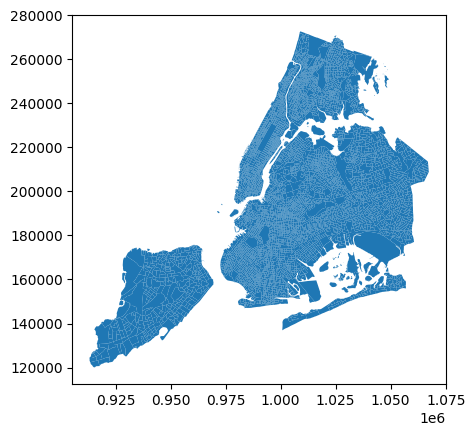

In [4]:
census_data.plot()

We can plot the **total population** per block group by selecting that column in our data frame and passing it to the `column` argument of the `plot` method. This will create a choropleth map where the color of each block group corresponds to its total population.

<Axes: >

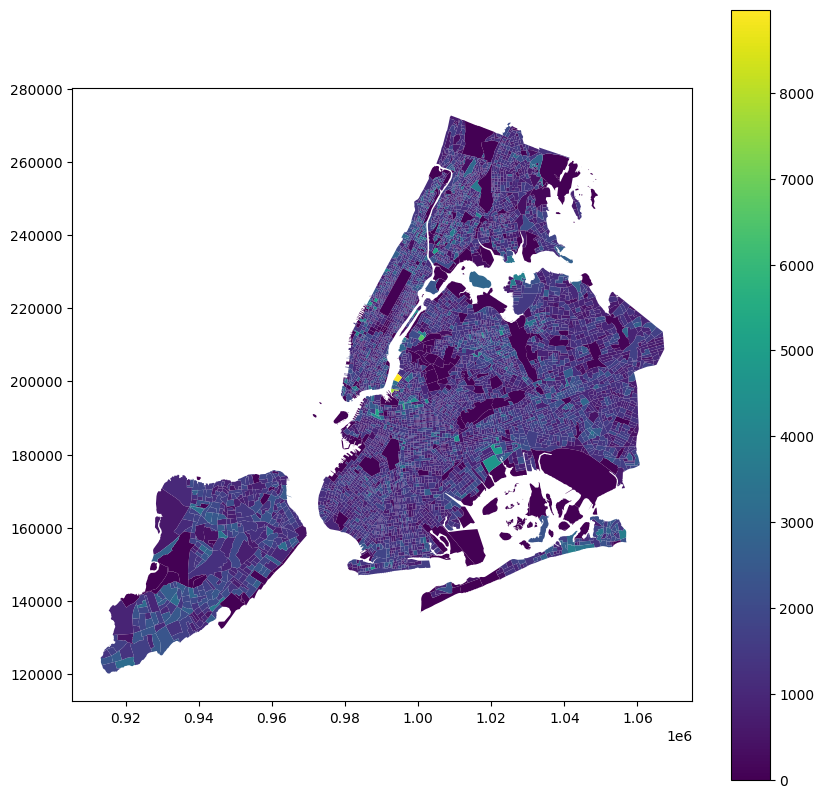

In [25]:
census_data.plot(
    column="Total Pop (Race/Ethnicity)",
    figsize=(10, 10),
    legend=True,
)

Our first mapping of a variable! However, it doesn't reveal much- you may or may not be able to spot block groups from each of the breaks in the legend. Let's take a look at the distribution of the population variable to understand why this is the case.

In [10]:
census_data["Total Pop (Race/Ethnicity)"].describe()

count    6593.000000
mean     1286.795692
std       684.693325
min         0.000000
25%       842.000000
50%      1202.000000
75%      1643.000000
max      8974.000000
Name: Total Pop (Race/Ethnicity), dtype: float64

<Axes: >

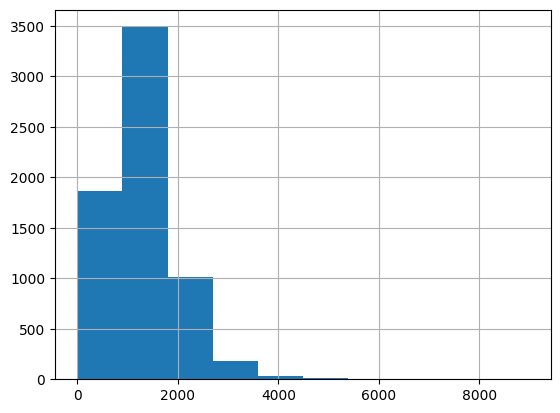

In [11]:
census_data["Total Pop (Race/Ethnicity)"].hist()

Based on the `describe()` and `hist()` outputs, we can see that the population variable is highly skewed, with a few block groups having very high populations and many block groups having low populations. We can use different classification methods to draw out these relationships more clearly.

<Axes: >

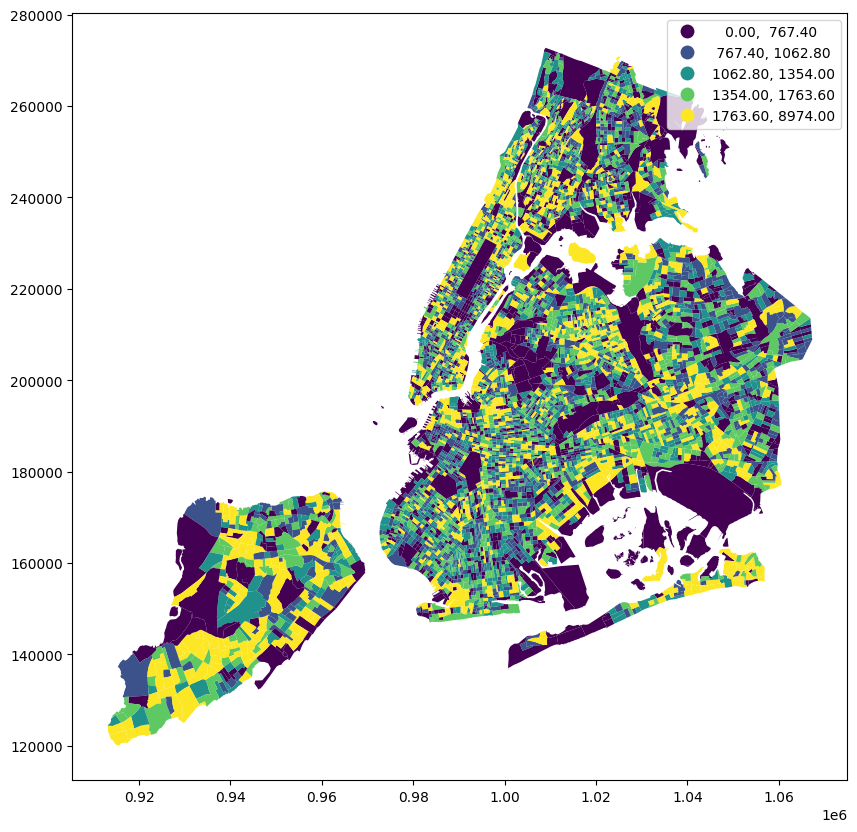

In [26]:
census_data.plot(
    column="Total Pop (Race/Ethnicity)",
    figsize=(10, 10),
    legend=True,
    scheme="quantiles",
)

Now we have a very different map! We're using quantiles to break the population variable into 5 classes, so each class has the same number of block groups. This allows us to understand the variation better to a degree, but still has an issue- we are looking at *population* and not *population density*. The block groups with the highest population are not necessarily the most densely populated, and vice versa. Let's take a look at the population density variable to see how it compares to the population variable.

In [8]:
census_data["pop_density"] = (
    census_data["Total Pop (Race/Ethnicity)"] / census_data["Area (Sq Mi)"]
)

Now that we have our normalized population variable, let's take a look at how it compares to the population variable.

<Axes: >

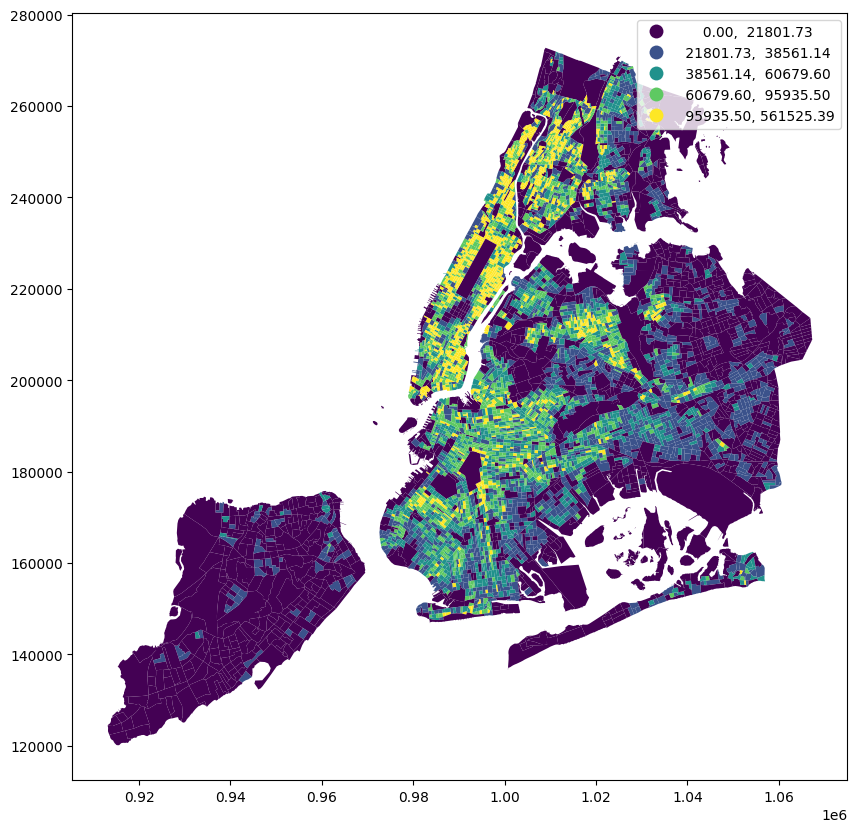

In [24]:
census_data.plot(
    column="pop_density", figsize=(10, 10), legend=True, scheme="quantiles"
)

A much different pattern emerges. We can see high-density block groups in Manhattan, the Bronx, Brooklyn, and parts of Queens, while eastern Queens and Staten Island are comparatively very low density. 

You may also notice that the low threshold for the first category is 0, which means there are block groups with no population. Let's separate those areas out so that we can separate the unpopulated areas from the low population areas. We can use filter statements to do so.

<Axes: >

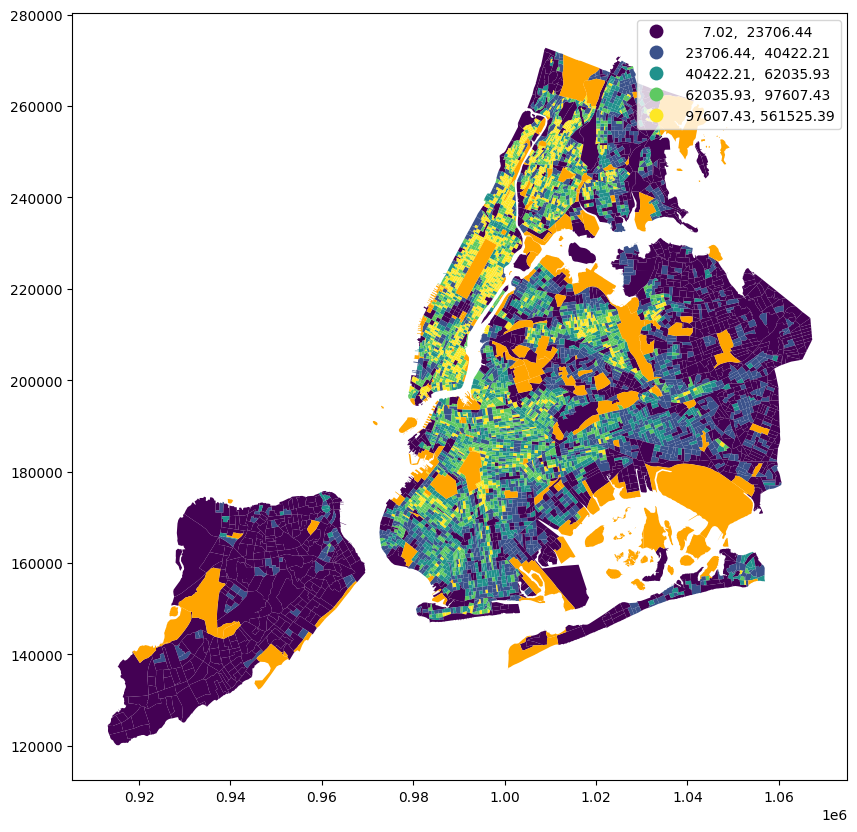

In [30]:
ax = census_data[census_data["pop_density"].gt(0)].plot(
    column="pop_density", figsize=(10, 10), legend=True, scheme="quantiles"
)

census_data[census_data["pop_density"].eq(0)].plot(
    ax=ax, color="orange", legend=True, label="0 pop density"
)

In [59]:
pop_density = census_data["pop_density"].to_numpy()
pop_density = np.nan_to_num(pop_density, nan=0)

scaled_pop_density = pop_density / pop_density.max() * 10000

normalizer = LogNorm(1, scaled_pop_density.max(), clip=True)
normalized_pop_density = normalizer(scaled_pop_density)

colors = apply_continuous_cmap(normalized_pop_density, Oranges_9)

In [60]:
layer = PolygonLayer.from_geopandas(
    # Select only a few attribute columns from the table
    gdf=census_data[
        [
            "GISJOIN",
            "pop_density",
            "geometry",
        ]
    ],
    extruded=True,
    get_elevation=scaled_pop_density,
    get_fill_color=colors,
)

/Users/marioag/miniforge3/envs/cdp26/lib/python3.14/site-packages/lonboard/_geoarrow/ops/reproject.py:116: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


In [64]:
view_state = {
    "longitude": -73.98416810282863,
    "latitude": 40.72651721370669,
    "zoom": 9.2,
    "pitch": 59.80465353190481,
    "bearing": 13.243243243243244,
}
m = Map(layer, view_state=view_state)
m